# LEAD — Large-scale Energy Anomaly Detection: EDA

Comprehensive exploratory data analysis for the Kaggle competition
[`energy-anomaly-detection`](https://www.kaggle.com/competitions/energy-anomaly-detection).

**Task:** binary classification — is each hourly electricity meter reading anomalous (`1`) or normal (`0`)?
**Metric:** AUC-ROC (submit probabilities). **Train:** 200 buildings. **Test:** 206 *held-out* buildings.

This notebook answers: dataset overview, target distribution, missing values, duplicates,
meter-reading distribution & artifacts, temporal/seasonal anomaly patterns, per-building
heterogeneity, weather relationships, correlation analysis, the *provided* engineered features,
and train/test drift.

## 0. Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4); plt.rcParams["figure.dpi"] = 100
RAW = Path("../data/raw")
FIG = Path("../reports/figures"); FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 120)

## 1. Dataset overview

The competition ships two flavours of each split:
- `train.csv` / `test.csv` — minimal: `building_id, timestamp, meter_reading (+anomaly on train)`
- `train_features.csv` / `test_features.csv` — same rows **plus** building metadata, weather,
  calendar features, lag features, and pre-computed **group-target-encoding** (`gte_*`) columns.

In [2]:
train = pd.read_csv(RAW/"train.csv", parse_dates=["timestamp"])
test  = pd.read_csv(RAW/"test.csv",  parse_dates=["timestamp"])
sub   = pd.read_csv(RAW/"sample_submission.csv")
print("train.csv   ", train.shape)
print("test.csv    ", test.shape)
print("submission  ", sub.shape, "| columns:", list(sub.columns))
train.head()

train.csv    (1749494, 4)
test.csv     (1800567, 4)
submission   (1800567, 2) | columns: ['row_id', 'anomaly']


,building_id,timestamp,meter_reading,anomaly
0,1,2016-01-01,NaN,0
1,32,2016-01-01,NaN,0
2,41,2016-01-01,NaN,0
3,55,2016-01-01,NaN,0
4,69,2016-01-01,NaN,0


In [3]:
print("Train columns:", list(train.columns))
print("Train memory (MB): %.1f" % (train.memory_usage(deep=True).sum()/1e6))
print()
print("Buildings — train: %d | test: %d | overlap: %d"
      % (train.building_id.nunique(), test.building_id.nunique(),
         len(set(train.building_id) & set(test.building_id))))
print("Time span train:", train.timestamp.min(), "->", train.timestamp.max())
print("Time span test :", test.timestamp.min(),  "->", test.timestamp.max())
print("Hours in 2016 (leap):", 366*24)

Train columns: ['building_id', 'timestamp', 'meter_reading', 'anomaly']
Train memory (MB): 56.0

Buildings — train: 200 | test: 206 | overlap: 0
Time span train: 2016-01-01 00:00:00 -> 2016-12-31 23:00:00
Time span test : 2016-01-01 00:00:00 -> 2016-12-31 23:00:00
Hours in 2016 (leap): 8784


## 2. Target distribution

Anomalies are **rare**. Class imbalance matters for thresholding/loss choices, though AUC-ROC
itself is rank-based.

anomaly
0    1712198
1      37296
Name: count, dtype: int64

Anomaly rate: 2.1318%  (1 in 47 rows)


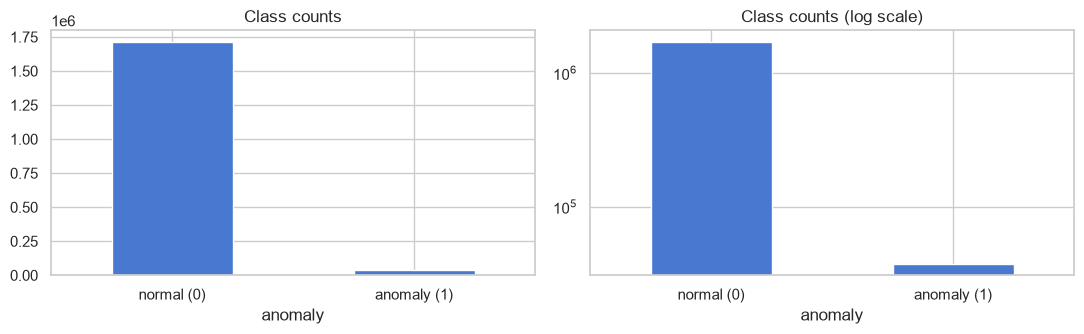

In [4]:
vc = train.anomaly.value_counts().sort_index()
rate = train.anomaly.mean()
print(vc); print("\nAnomaly rate: %.4f%%  (1 in %.0f rows)" % (rate*100, 1/rate))
fig, ax = plt.subplots(1, 2, figsize=(11,3.5))
vc.plot(kind="bar", ax=ax[0]); ax[0].set_title("Class counts"); ax[0].set_xticklabels(["normal (0)","anomaly (1)"], rotation=0)
vc.plot(kind="bar", ax=ax[1], logy=True); ax[1].set_title("Class counts (log scale)"); ax[1].set_xticklabels(["normal (0)","anomaly (1)"], rotation=0)
plt.tight_layout(); plt.savefig(FIG/"target_distribution.png", bbox_inches="tight"); plt.show()

### 2a. Anomaly rate per building — is the signal concentrated?

Buildings with ZERO anomalies: 0 / 200
Per-building anomaly rate — describe:
count    200.000000
mean       0.021310
std        0.011573
min        0.005806
25%        0.012658
50%        0.019354
75%        0.027294
max        0.088229
Name: rate, dtype: float64


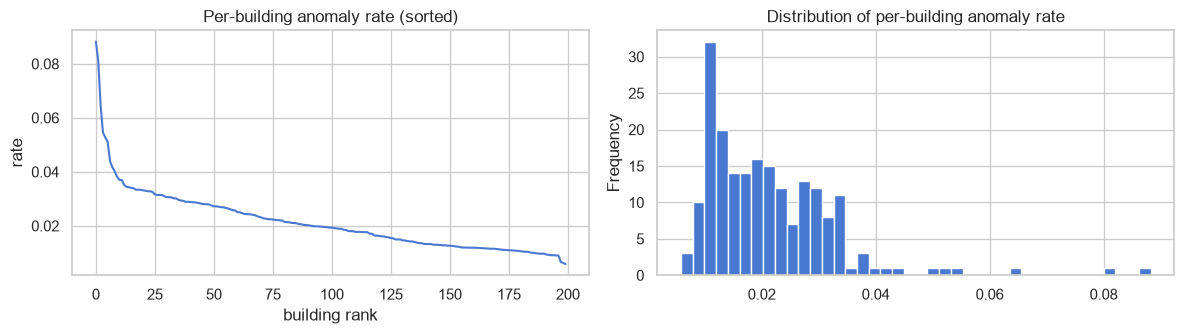

In [5]:
per_b = train.groupby("building_id").anomaly.agg(["mean","sum","count"]).rename(columns={"mean":"rate","sum":"n_anom","count":"n_rows"})
print("Buildings with ZERO anomalies: %d / %d" % ((per_b.n_anom==0).sum(), len(per_b)))
print("Per-building anomaly rate — describe:"); print(per_b.rate.describe())
fig, ax = plt.subplots(1,2, figsize=(12,3.5))
per_b.rate.sort_values(ascending=False).reset_index(drop=True).plot(ax=ax[0]); ax[0].set_title("Per-building anomaly rate (sorted)"); ax[0].set_xlabel("building rank"); ax[0].set_ylabel("rate")
per_b.rate.plot(kind="hist", bins=40, ax=ax[1]); ax[1].set_title("Distribution of per-building anomaly rate")
plt.tight_layout(); plt.savefig(FIG/"anomaly_rate_per_building.png", bbox_inches="tight"); plt.show()

## 3. Missing values & duplicates

In [6]:
print("=== train.csv missingness ===")
print((train.isna().mean()*100).round(3).astype(str)+" %")
miss_reading = train.meter_reading.isna()
print("\nmeter_reading missing: %d rows (%.2f%%)" % (miss_reading.sum(), miss_reading.mean()*100))
print("anomalies among missing-reading rows:", int(train.loc[miss_reading,"anomaly"].sum()),
      "  (missing readings are never labelled anomalous)")
print("\nDuplicates — full row:", train.duplicated().sum(),
      "| (building_id, timestamp):", train.duplicated(['building_id','timestamp']).sum())

=== train.csv missingness ===
building_id        0.0 %
timestamp          0.0 %
meter_reading    6.153 %
anomaly            0.0 %
dtype: str

meter_reading missing: 107653 rows (6.15%)
anomalies among missing-reading rows: 0   (missing readings are never labelled anomalous)



Duplicates — full row: 0 | (building_id, timestamp): 0


### 3a. Where are the missing readings? (per building & over time)

Buildings with >0 missing readings: 177
Top 5 buildings by missing fraction:
 building_id
144    61.6
112    60.9
107    43.4
69     41.6
886    40.3
Name: miss, dtype: float64


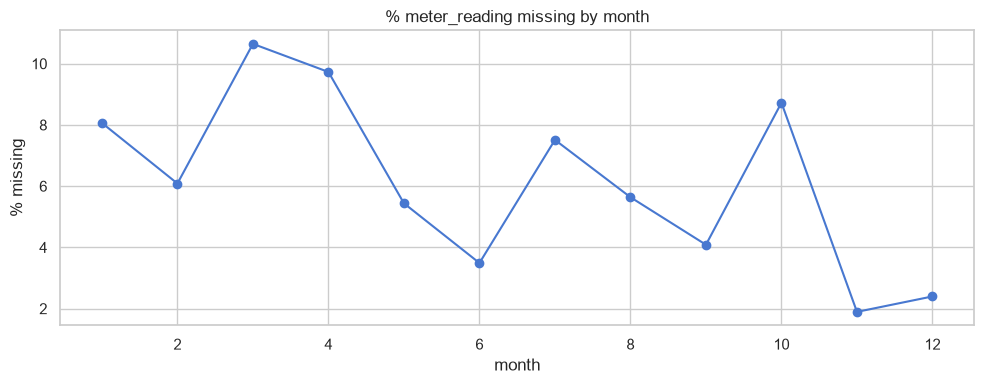

In [7]:
mb = train.assign(miss=miss_reading).groupby("building_id").miss.mean()
print("Buildings with >0 missing readings: %d" % (mb>0).sum())
print("Top 5 buildings by missing fraction:\n", (mb.sort_values(ascending=False).head()*100).round(1))
by_month = train.assign(miss=miss_reading, month=train.timestamp.dt.month).groupby("month").miss.mean()*100
ax = by_month.plot(marker="o"); ax.set_title("% meter_reading missing by month"); ax.set_ylabel("% missing")
plt.tight_layout(); plt.savefig(FIG/"missing_by_month.png", bbox_inches="tight"); plt.show()

## 4. Meter reading distribution & known artifacts

The 1st-place solution exploited two artifacts: readings of exactly **1.0** and the **endpoints**
of each building's series. We check the reading distribution, zeros, and the `==1.0` mass, split
by anomaly label.

meter_reading describe:
count    1.641841e+06
mean     1.799018e+02
std      3.959129e+02
min      0.000000e+00
25%      3.000000e+01
50%      8.410000e+01
75%      1.990000e+02
max      6.596890e+03
Name: meter_reading, dtype: float64

== exactly 0 : 25 | anomaly rate among them: 0.000
== exactly 1 : 17059 | anomaly rate among them: 1.000
== negative  : 0


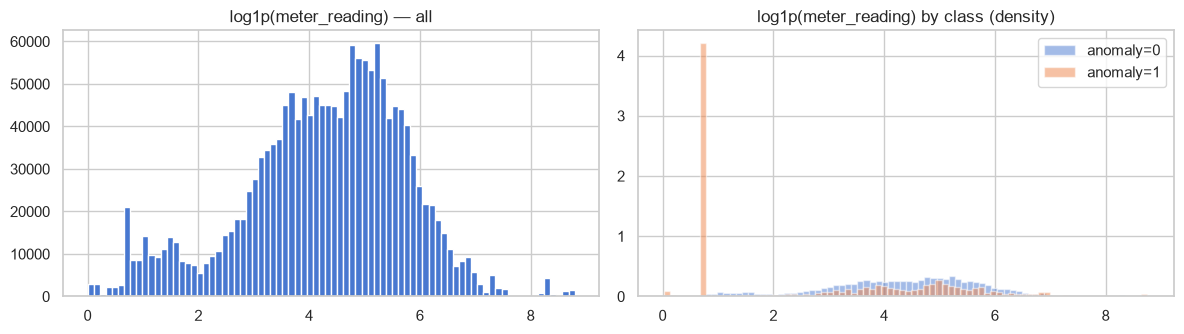

In [8]:
r = train.dropna(subset=["meter_reading"])
print("meter_reading describe:"); print(r.meter_reading.describe())
print("\n== exactly 0 :", (r.meter_reading==0).sum(), "| anomaly rate among them: %.3f" % r.loc[r.meter_reading==0,"anomaly"].mean())
print("== exactly 1 :", (r.meter_reading==1).sum(), "| anomaly rate among them: %.3f" % r.loc[r.meter_reading==1,"anomaly"].mean())
print("== negative  :", (r.meter_reading<0).sum())
fig, ax = plt.subplots(1,2, figsize=(12,3.5))
np.log1p(r.meter_reading.clip(lower=0)).hist(bins=80, ax=ax[0]); ax[0].set_title("log1p(meter_reading) — all")
for lbl,g in r.groupby("anomaly"):
    ax[1].hist(np.log1p(g.meter_reading.clip(lower=0)), bins=80, density=True, alpha=.5, label=f"anomaly={lbl}")
ax[1].legend(); ax[1].set_title("log1p(meter_reading) by class (density)")
plt.tight_layout(); plt.savefig(FIG/"meter_reading_dist.png", bbox_inches="tight"); plt.show()

## 5. Temporal / seasonal anomaly patterns

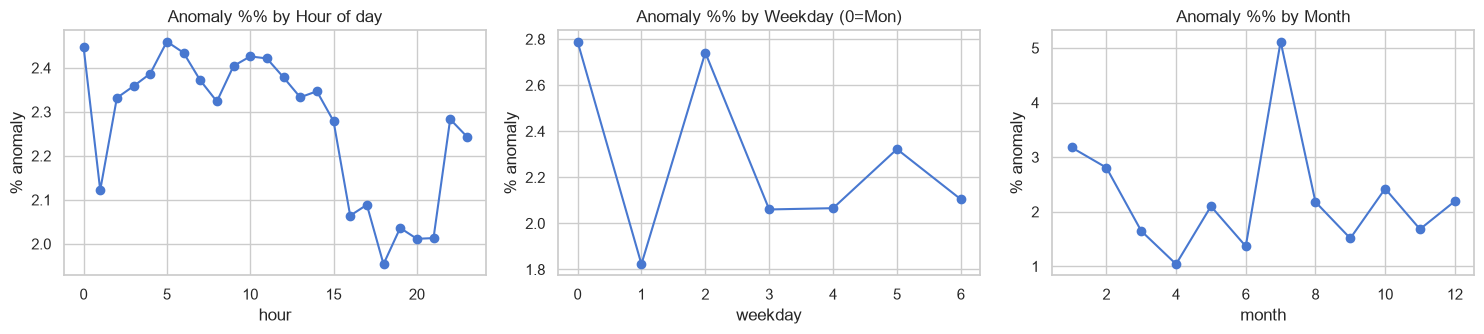

In [9]:
tt = train.dropna(subset=["meter_reading"]).copy()
tt["hour"]=tt.timestamp.dt.hour; tt["weekday"]=tt.timestamp.dt.weekday; tt["month"]=tt.timestamp.dt.month
fig, ax = plt.subplots(1,3, figsize=(15,3.5))
for a,col,ttl in zip(ax,["hour","weekday","month"],["Hour of day","Weekday (0=Mon)","Month"]):
    (tt.groupby(col).anomaly.mean()*100).plot(marker="o", ax=a); a.set_title("Anomaly %% by "+ttl); a.set_ylabel("% anomaly")
plt.tight_layout(); plt.savefig(FIG/"anomaly_by_time.png", bbox_inches="tight"); plt.show()

## 6. Provided engineered features (`train_features.csv`)

Load the rich file to inspect metadata, weather, and the pre-computed `gte_*` (group target
encoding) columns. **Caveat:** the `gte_*` columns are target-derived; for honest validation we
must understand how they were built (likely global on train) before trusting them — they can leak.

In [10]:
feat = pd.read_csv(RAW/"train_features.csv", parse_dates=["timestamp"])
print("train_features:", feat.shape, "| memory %.1f MB" % (feat.memory_usage(deep=True).sum()/1e6))
cols = list(feat.columns)
meta = ["site_id","primary_use","square_feet","year_built","floor_count"]
weather = ["air_temperature","cloud_coverage","dew_temperature","precip_depth_1_hr","sea_level_pressure","wind_direction","wind_speed"]
gte = [c for c in cols if c.startswith("gte")]
print("\n# metadata:", meta)
print("# weather:", weather)
print("# gte_ (target-encoded):", len(gte), "cols ->", gte)
print("\nMissingness of metadata+weather (%):")
print((feat[meta+weather].isna().mean()*100).round(2))

train_features: (1749494, 57) | memory 1491.9 MB

# metadata: ['site_id', 'primary_use', 'square_feet', 'year_built', 'floor_count']
# weather: ['air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed']
# gte_ (target-encoded): 16 cols -> ['gte_hour', 'gte_weekday', 'gte_month', 'gte_building_id', 'gte_primary_use', 'gte_site_id', 'gte_meter', 'gte_meter_hour', 'gte_meter_weekday', 'gte_meter_month', 'gte_meter_building_id', 'gte_meter_primary_use', 'gte_meter_site_id', 'gte_meter_building_id_hour', 'gte_meter_building_id_weekday', 'gte_meter_building_id_month']

Missingness of metadata+weather (%):
site_id               0.0
primary_use           0.0
square_feet           0.0
year_built            0.0
floor_count           0.0
air_temperature       0.0
cloud_coverage        0.0
dew_temperature       0.0
precip_depth_1_hr     0.0
sea_level_pressure    0.0
wind_direction        0.0
wind_speed            0.0
dtype: f

### 6a. Building metadata distributions & anomaly by `primary_use`

primary_use counts (buildings):
 primary_use
Education                        80
Office                           62
Entertainment/public assembly    23
Lodging/residential              13
Public services                   7
Healthcare                        5
Services                          3
Parking                           2
Manufacturing/industrial          2
Other                             1
Food sales and service            1
Religious worship                 1
Name: count, dtype: int64


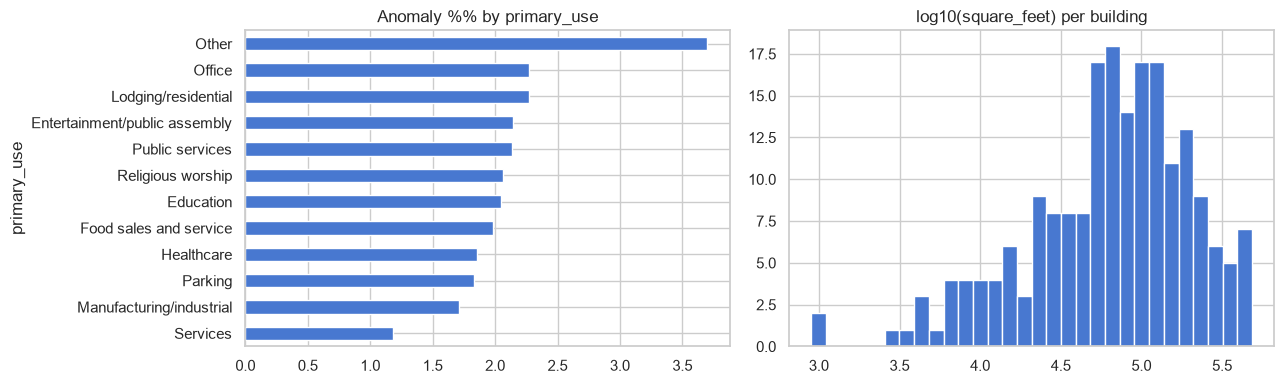

In [11]:
bmeta = feat.groupby("building_id")[meta].first()
print("primary_use counts (buildings):\n", bmeta.primary_use.value_counts())
fig, ax = plt.subplots(1,2, figsize=(13,4))
(feat.groupby("primary_use").anomaly.mean()*100).sort_values().plot(kind="barh", ax=ax[0]); ax[0].set_title("Anomaly %% by primary_use")
np.log10(bmeta.square_feet.clip(lower=1)).hist(bins=30, ax=ax[1]); ax[1].set_title("log10(square_feet) per building")
plt.tight_layout(); plt.savefig(FIG/"metadata_anomaly.png", bbox_inches="tight"); plt.show()

## 7. Weather relationships

Correlation of weather with anomaly:
 wind_direction       -0.0186
cloud_coverage       -0.0085
precip_depth_1_hr    -0.0058
air_temperature       0.0010
dew_temperature       0.0025
wind_speed            0.0091
sea_level_pressure    0.0093
Name: anomaly, dtype: float64


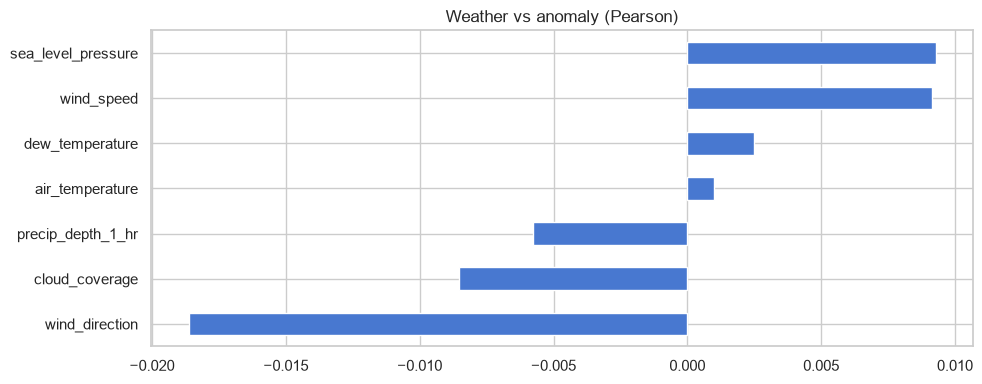

In [12]:
wdf = feat.dropna(subset=["meter_reading"])
corr_w = wdf[weather+["anomaly"]].corr()["anomaly"].drop("anomaly").sort_values()
print("Correlation of weather with anomaly:\n", corr_w.round(4))
ax = corr_w.plot(kind="barh"); ax.set_title("Weather vs anomaly (Pearson)")
plt.tight_layout(); plt.savefig(FIG/"weather_corr.png", bbox_inches="tight"); plt.show()

## 8. Correlation analysis

Numeric correlation heatmap across reading, weather, calendar and a sample of `gte_*` features,
to spot redundancy and leakage-strength of the provided target encodings.

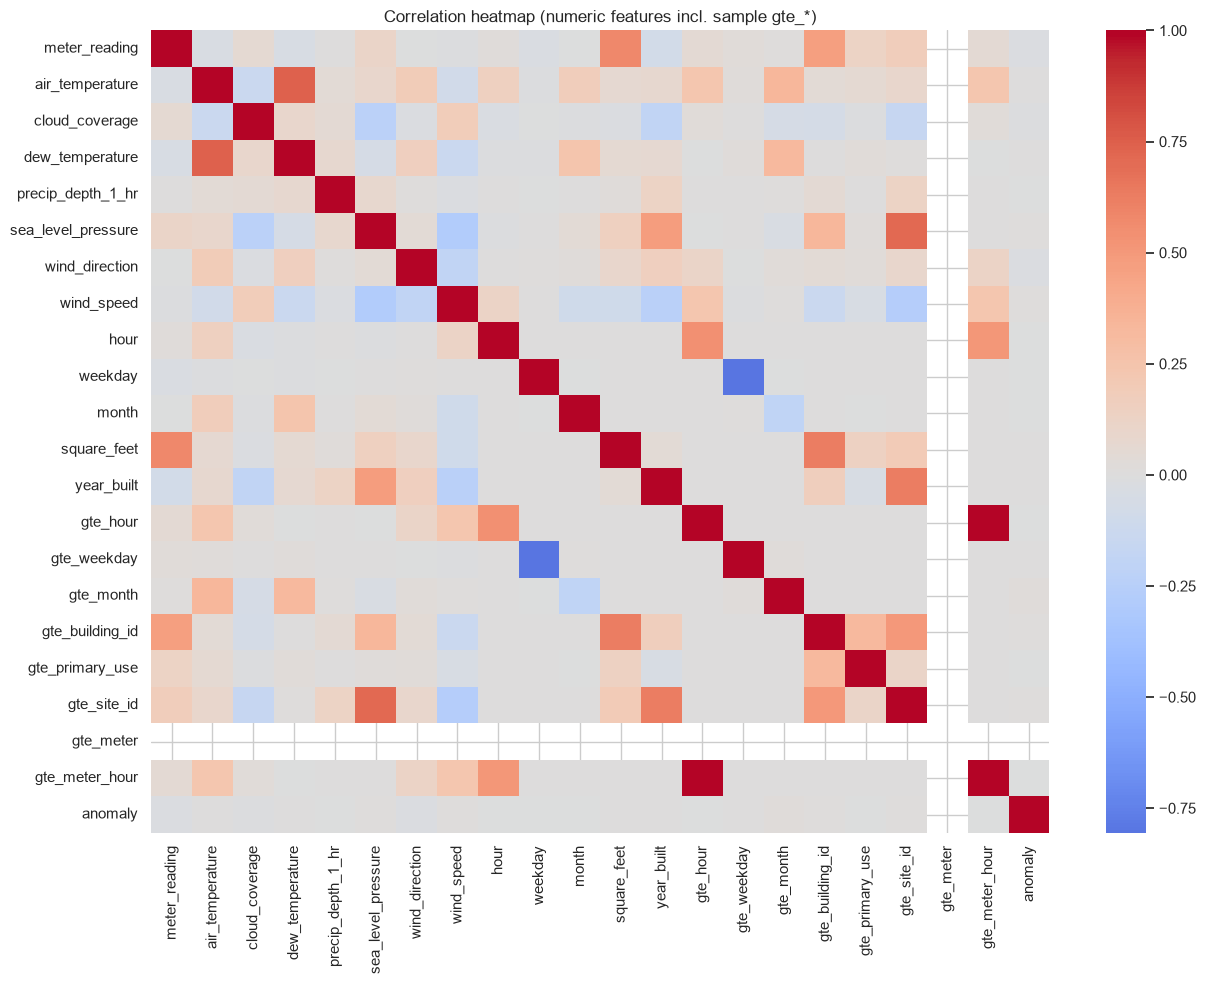

Top |correlation| with anomaly:
meter_reading         0.0195
gte_month             0.0187
wind_direction        0.0170
cloud_coverage        0.0102
gte_building_id       0.0096
gte_site_id           0.0094
weekday               0.0081
wind_speed            0.0076
sea_level_pressure    0.0067
hour                  0.0064
gte_primary_use       0.0063
precip_depth_1_hr     0.0051
month                 0.0049
year_built            0.0036
gte_weekday           0.0027
Name: anomaly, dtype: float64


In [13]:
num = ["meter_reading"]+weather+["hour","weekday","month","square_feet","year_built"]+gte[:8]+["anomaly"]
num = [c for c in num if c in feat.columns]
cm = feat[num].corr()
plt.figure(figsize=(13,10)); sns.heatmap(cm, cmap="coolwarm", center=0, annot=False, square=False)
plt.title("Correlation heatmap (numeric features incl. sample gte_*)"); plt.tight_layout()
plt.savefig(FIG/"correlation_heatmap.png", bbox_inches="tight"); plt.show()
print("Top |correlation| with anomaly:")
print(cm["anomaly"].drop("anomaly").abs().sort_values(ascending=False).head(15).round(4))

## 9. Train vs test drift

Test buildings are **disjoint** from train, so per-building generalization is the whole game.
Compare metadata/weather distributions across splits.

Buildings — train: 200 | test: 206
Sites — train: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(14), np.int64(15)] 
       test: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]

primary_use share (per building):
                                train  test
primary_use                               
Education                       40.0  38.8
Office                          31.0  33.0
Entertainment/public assembly   11.5   9.7
Lodging/residential              6.5   6.8
Public services                  3.5   4.4
Healthcare                       2.5   2.4
Services                         1.5   1.0
Parking                          1.0   0.0
Manufacturing/industrial         1.0   0.0
Other                            0.5   1.5
Food sal

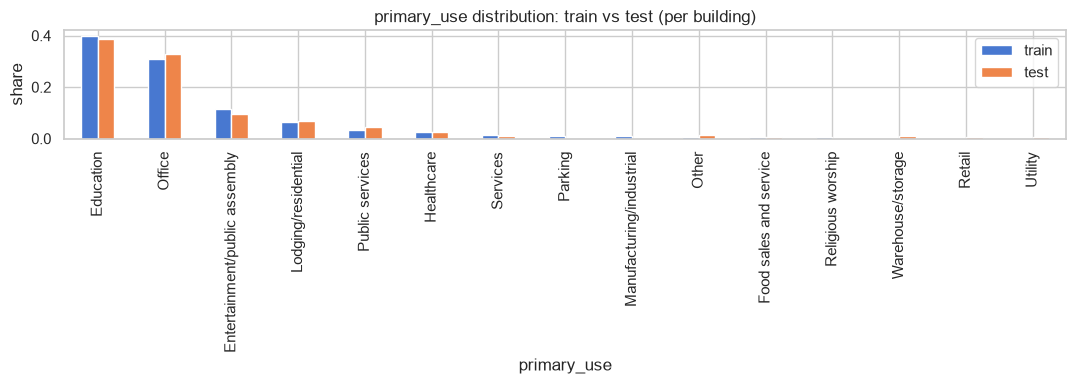

In [14]:
tfeat = pd.read_csv(RAW/"test_features.csv", parse_dates=["timestamp"], usecols=["building_id","timestamp","site_id","primary_use","square_feet","year_built"]+weather)
print("Buildings — train: %d | test: %d" % (feat.building_id.nunique(), tfeat.building_id.nunique()))
print("Sites — train:", sorted(feat.site_id.unique()), "\n       test:", sorted(tfeat.site_id.unique()))
pu = pd.concat([feat.groupby("building_id").primary_use.first().value_counts(normalize=True).rename("train"),
                tfeat.groupby("building_id").primary_use.first().value_counts(normalize=True).rename("test")], axis=1).fillna(0)
print("\nprimary_use share (per building):\n", (pu*100).round(1))
ax = pu.plot(kind="bar", figsize=(11,4)); ax.set_title("primary_use distribution: train vs test (per building)"); ax.set_ylabel("share")
plt.tight_layout(); plt.savefig(FIG/"train_test_drift.png", bbox_inches="tight"); plt.show()

In [15]:
# numeric drift: square_feet & weather summary
def summ(df, cols): return df[cols].describe().T[["mean","50%","std","min","max"]]
print("TRAIN weather/size summary:"); print(summ(feat, ["square_feet"]+weather).round(2))
print("\nTEST weather/size summary:"); print(summ(tfeat, ["square_feet"]+weather).round(2))

TRAIN weather/size summary:
                         mean      50%        std    min       max
square_feet         106565.83  71088.0  102553.09  898.0  484376.0
air_temperature         16.51     16.7      10.32  -29.9      47.2
cloud_coverage         116.93      4.0     126.39    0.0     255.0
dew_temperature          8.81      9.7       9.87  -36.0      26.1
precip_depth_1_hr        0.13      0.0       6.19   -2.0     343.0
sea_level_pressure    1009.37   1014.6      17.99  967.2    1045.5
wind_direction        6779.09    200.0   19706.21    0.0   65535.0
wind_speed               3.21      3.1       2.23   -1.0      19.0

TEST weather/size summary:


                         mean      50%        std     min       max
square_feet         101931.71  58196.0  120312.17  1102.0  850354.0
air_temperature         16.52     16.7      10.32   -29.9      47.2
cloud_coverage         114.91      4.0     126.19     0.0     255.0
dew_temperature          8.78      9.4       9.89   -36.0      26.1
precip_depth_1_hr        0.13      0.0       6.08    -2.0     343.0
sea_level_pressure    1009.51   1014.6      17.87   967.2    1045.5
wind_direction        6937.42    200.0   19915.02     0.0   65535.0
wind_speed               3.19      3.1       2.23    -1.0      19.0


## 10. Summary of findings

See `reports/EDA_FINDINGS.md` for the written Q&A. Headline points are printed below.

In [16]:
print('''KEY TAKEAWAYS
- Target: anomaly rate ~2.13%% (rare). EVERY building has anomalies (0 zero-anomaly buildings);
  per-building rate ranges 0 -> ~8.8%% -> meaningful per-building heterogeneity.
- meter_reading missing ~6.2%% of rows; missing readings are NEVER anomalies (still scored -> predict low).
- STRONG RULE: meter_reading == 1.0 -> anomaly in 99.97%% of cases (17053/17059 rows, 150 buildings).
- No duplicate rows or (building,timestamp) collisions.
- Weather columns show 0%% NaN because missing was sentinel-imputed (e.g. cloud_coverage==255 ~46%% of rows).
- Linear correlation with anomaly is tiny (all |r|<0.02) -> need trees/interactions + per-building context.
- Test buildings are disjoint from train -> GroupKFold by building_id is mandatory.
- Competition provides rich engineered features incl. gte_* target encodings (verify leakage before use).''')

KEY TAKEAWAYS
- Target: anomaly rate ~2.13%% (rare). EVERY building has anomalies (0 zero-anomaly buildings);
  per-building rate ranges 0 -> ~8.8%% -> meaningful per-building heterogeneity.
- meter_reading missing ~6.2%% of rows; missing readings are NEVER anomalies (still scored -> predict low).
- STRONG RULE: meter_reading == 1.0 -> anomaly in 99.97%% of cases (17053/17059 rows, 150 buildings).
- No duplicate rows or (building,timestamp) collisions.
- Weather columns show 0%% NaN because missing was sentinel-imputed (e.g. cloud_coverage==255 ~46%% of rows).
- Linear correlation with anomaly is tiny (all |r|<0.02) -> need trees/interactions + per-building context.
- Test buildings are disjoint from train -> GroupKFold by building_id is mandatory.
- Competition provides rich engineered features incl. gte_* target encodings (verify leakage before use).
